In [35]:

from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
     

In [36]:
## generate data with 2 features (multiple regression)
X,y = make_regression(n_samples=100, n_features=2, n_informative=2, n_targets=1, noise=50)


In [37]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1],'target':y})


In [38]:
df


,feature1,feature2,target
0,-0.037549,0.241236,-41.602995
1,-0.068459,0.307310,52.089006
2,1.048198,-0.827948,58.977723
3,-0.033696,0.377531,-32.084680
4,1.054387,-0.720319,60.487742
...,...,...,...
95,-0.085775,-1.498880,-131.851325
96,1.010410,-2.190943,-131.752140
97,0.405515,-0.436893,-55.849662
98,0.242971,0.797816,50.712367


In [39]:
df.shape

(100, 3)

In [40]:


fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.show()

In [41]:

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=3)

In [42]:
from sklearn.linear_model import LinearRegression



In [43]:
lr = LinearRegression()

In [44]:
lr.fit(x_train,y_train)

LinearRegression()

In [45]:
y_pred=lr.predict(x_test)

In [46]:

print("MAE",mean_absolute_error(y_test,y_pred))
print("MSE",mean_squared_error(y_test,y_pred))
print("R2 score",r2_score(y_test,y_pred))

MAE 38.26509289270179
MSE 2270.350926763338
R2 score 0.7863213642508065


In [47]:

x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)

# prepare grid for prediction
final = np.vstack((xGrid.ravel().reshape(1,100),
                   yGrid.ravel().reshape(1,100))).T

# now predict
z_final = lr.predict(final).reshape(10,10)
z = z_final


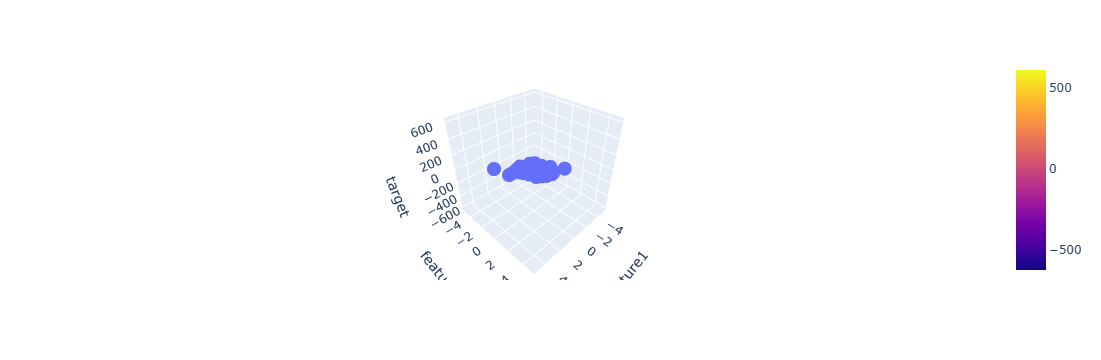

In [48]:

fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

In [49]:
lr.coef_


array([63.84564976, 59.10382661])

In [50]:
lr.intercept_


-7.587169791262621